# Chapter 57 — Deep Learning for Sequential Strain Data
### *Modern Strain Gage Technology* — Companion Notebook

**A strain record is a story told in order — the moment we shuffle the samples, we lose the plot.**

Companion notebook to Chapter 57 — Deep Learning for Sequential Strain Data.

Strain is almost always a time-series: measurements ordered by time, where the current reading depends partly on recent history. Classical machine learning models treat each sample independently, discarding this temporal structure. Recurrent neural networks (RNNs) and their more capable successors — Long Short-Term Memory (LSTM) networks and Transformer architectures — are designed to exploit sequential structure by maintaining an internal state that summarizes relevant history and carries it forward through time.

The notebook below uses a *sliding-window* approach as a conceptually accessible surrogate for recurrent networks: a feedforward network is given the previous 20 strain samples as inputs and asked to predict the next one. This is mathematically equivalent to a restricted recurrent model with a fixed memory window of 20 steps, and it captures most of the practical benefit of sequential modeling for smooth deterministic signals. The extension to a true LSTM is architectural rather than conceptual — the temporal dependency is already explicit in the window structure. We keep the model deliberately light (a small multilayer perceptron in scikit-learn) so the notebook runs in seconds in Colab without a GPU; the *concepts* transfer directly to a Keras or PyTorch LSTM.

For structural health monitoring, sequential models are most valuable when the anomaly is temporal in character: a gradually widening crack that shifts the resonance frequency over hundreds of cycles, a progressive stiffness reduction that changes the signal envelope rather than its instantaneous value, or an impact event that produces a step change in the structural response pattern. These signatures are invisible to feature-based models that process each loading cycle in isolation — which is why sequential modeling is the frontier of AI-based structural health monitoring.

**This notebook demonstrates:**
1. One-step-ahead strain prediction using a sliding-window neural network trained on a simulated multi-frequency, amplitude-modulated strain signal — with a prediction overlay, an error panel, and an R² evaluation.

In [1]:
# Colab setup (uncomment on first run):
# !pip install numpy matplotlib scikit-learn

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All saved figures land in the chapter's media directory used by the book.
OUT_DIR = Path("../src/media/ch57")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — One-Step-Ahead Strain Prediction with a Sliding-Window Neural Network

The simulated signal combines three modal components at 0.20, 0.55, and 1.10 Hz (with phase offsets), scaled by a slow 0.03 Hz amplitude modulation and buried in Gaussian noise at σ = 4 με, sampled at 100 Hz for 60 seconds. This creates a quasi-periodic signal whose envelope drifts over time — enough structure to be predictable from recent history, but enough noise and complexity that a trivial persistence model (predict next = current) would perform poorly.

The sliding window converts the time-series problem into a standard supervised regression problem: each training sample consists of 20 consecutive strain readings (the input window) and the 21st reading (the target). An 80/20 train-test split preserves temporal ordering — the model is evaluated on the last 20% of the time series, which it has never seen during training. This is the correct evaluation protocol for time-series models; random splitting would leak future information into the training set and inflate the apparent R².

The prediction overlay plot shows the first 200 held-out test samples with true and predicted strain superimposed, and an error panel below. A well-trained sliding-window model should track the signal envelope closely, with errors visible mainly in the noise component and at phase transitions. The R² quantifies how much of the total variance in the test signal is explained by the model — values above 0.95 indicate that the temporal structure has been successfully learned.

*A note on terminology:* the model here is a small feedforward multilayer perceptron (an `MLPRegressor`), not a literal LSTM. As the introduction explained, a fixed-length window makes the temporal dependence explicit, so the MLP acts as a fast surrogate for a recurrent network. The saved figure keeps the `lstm` filename used by the book, but the plot is titled honestly as a sliding-window prediction.

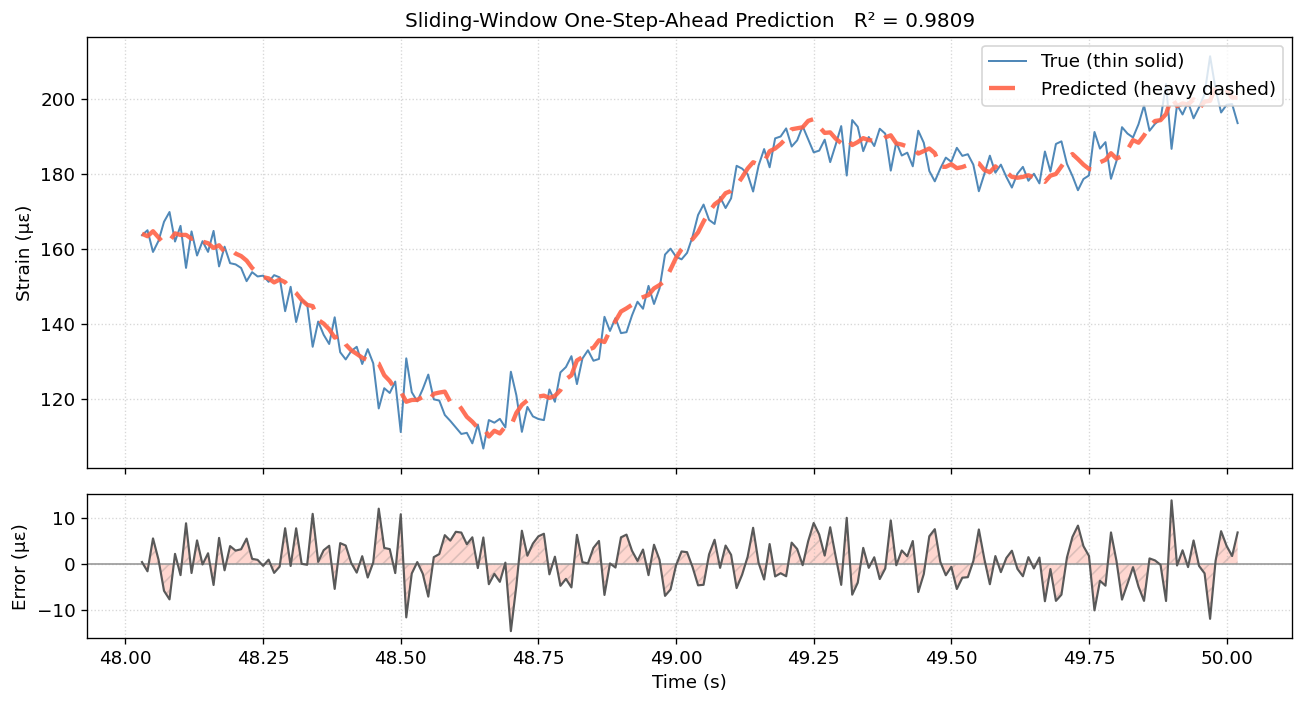

R2=0.9809  err mean=0.684  err std=4.740


In [2]:
# Synthetic fatigue strain: three modal components + slow amplitude modulation
# + Gaussian noise. A feedforward MLP on a sliding window is used as a fast,
# dependency-light surrogate for an LSTM doing one-step-ahead prediction; the
# fixed window makes the temporal dependence explicit.

SEED = 42               # seed for the synthetic-signal noise draw
NN_RANDOM_STATE = 0     # MLP weight-init seed (fixed for reproducibility)
FS = 100.0              # sampling rate (Hz)
DURATION = 60.0         # record length (s)
BASELINE = 200.0        # mean strain level (με)
NOISE_STD = 4.0         # measurement noise, 1 sigma (με)
WINDOW = 20             # input length: previous 20 samples predict the next
TRAIN_FRAC = 0.8        # fraction of windows used for training (temporal split)
PLOT_STEPS = 200        # number of held-out test steps shown in the overlay


def make_windows(series, window):
    """Build sliding-window inputs and one-step-ahead targets.

    Each row of X holds ``window`` consecutive samples; the matching entry of
    y is the sample immediately following that window. The source ordering is
    preserved (no shuffling), which is what makes a later temporal train/test
    split leak-free.

    Returns
    -------
    X : ndarray, shape (n_windows, window)
    y : ndarray, shape (n_windows,)
    """
    n_windows = len(series) - window - 1
    X = np.array([series[i:i + window] for i in range(n_windows)])
    y = np.array([series[i + window] for i in range(n_windows)])
    return X, y


# --- Synthesize the strain record ---------------------------------------
np.random.seed(SEED)
t = np.arange(0, DURATION, 1 / FS)
envelope = 1.0 + 0.35 * np.sin(2 * np.pi * 0.03 * t)          # slow amplitude modulation
sig = (BASELINE
       + envelope * (50 * np.sin(2 * np.pi * 0.20 * t)         # component 1
                     + 22 * np.sin(2 * np.pi * 0.55 * t + 0.5)  # component 2
                     + 12 * np.sin(2 * np.pi * 1.10 * t + 1.1)) # component 3
       + np.random.normal(0, NOISE_STD, len(t)))

# --- Frame as supervised one-step-ahead regression ----------------------
X, y = make_windows(sig, WINDOW)

# Temporal (non-shuffled) split: train on the past, test on the held-out
# future. Random splitting would leak future samples into training.
split = int(TRAIN_FRAC * len(X))
X_tr, X_te, y_tr, y_te = X[:split], X[split:], y[:split], y[split:]

# Standardize using training statistics only (no leakage from the test set).
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

nn = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=800,
                  random_state=NN_RANDOM_STATE).fit(X_tr_s, y_tr)
y_pred = nn.predict(X_te_s)

# --- Evaluate and plot --------------------------------------------------
t_test = t[split + WINDOW:split + WINDOW + len(y_te)]
r2 = r2_score(y_te, y_pred)
err = y_pred[:PLOT_STEPS] - y_te[:PLOT_STEPS]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
# Two redundant channels separate the curves: colour AND line weight/style,
# so the plot survives a black-and-white printing of the book.
ax1.plot(t_test[:PLOT_STEPS], y_te[:PLOT_STEPS], color='steelblue', lw=1.2,
         alpha=0.95, ls='-', label='True (thin solid)')
ax1.plot(t_test[:PLOT_STEPS], y_pred[:PLOT_STEPS], color='tomato', lw=2.6,
         alpha=0.9, ls=(0, (6, 3)), label='Predicted (heavy dashed)')
ax1.set_ylabel('Strain (με)')
ax1.set_title('Sliding-Window One-Step-Ahead Prediction   R² = %.4f' % r2)
ax1.legend(loc='upper right'); ax1.grid(True, ls=':', alpha=0.5)

ax2.axhline(0, color='0.6', lw=1)
ax2.plot(t_test[:PLOT_STEPS], err, color='0.35', lw=1.3)
ax2.fill_between(t_test[:PLOT_STEPS], err, 0, facecolor='tomato', alpha=0.25,
                 hatch='///', edgecolor='0.45', linewidth=0.0)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Error (με)')
ax2.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig57_nb1_lstm_sequence_prediction.png', bbox_inches='tight', dpi=150)
plt.show()
print('R2=%.4f  err mean=%.3f  err std=%.3f' % (r2, err.mean(), err.std()))

---
## Where to take this next

This notebook is a starting point. Three concrete extensions turn it into a genuine sequence-modeling study:

1. **Swap in a real recurrent network.** Replace the sliding-window `MLPRegressor` with a true LSTM or GRU (Keras or PyTorch), feeding the same windows shaped as `(samples, timesteps, 1)`. Compare one-step-ahead R² and wall-clock training time against the MLP surrogate here — for this smooth, short-memory signal you will likely find the MLP is competitive, which is exactly the point of Table 57.1: match the architecture to the signal, not to the hype.

2. **Test multi-step (rolling) forecasting.** The figure caption warns that one-step-ahead accuracy does not prove long-horizon forecasting. Feed the model's own prediction back in as the newest sample and roll forward 50–100 steps, then plot how the error grows. This exposes error accumulation and is the honest test when the deployment goal is prediction into the future rather than filtering the present.

3. **Turn it into an anomaly detector.** Inject a regime change partway through the record — a step in stiffness, an added crack-driven harmonic, or a growing amplitude — but train only on the earlier, healthy portion. Watch whether the prediction error in the held-out region spikes when the structure's behavior departs from what the model learned. That residual-monitoring pattern is the practical bridge from this toy example to real structural health monitoring.